In [1]:
import keras
import pandas as pd
import numpy as np
# import math
import matplotlib.pyplot as plt
# import os
# import tensorflow as tf
import sys
print(sys.executable)
import seaborn as sns
import IPython.display as display

import Data_Analysis_Code as da


import sklearn.preprocessing as prep
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay




I0000 00:00:1786421241.821177  194215 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786421241.822191  194215 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786421241.977594  194215 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786421244.467632  194215 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

/home/gr00vingm0nkey/vscode/kaggle/Data/.venv/bin/python


In [2]:
import importlib

importlib.reload(da)

print(dir(da))
print(dir())

pd.set_option('display.max_seq_items', None)
pd.set_option('display.max_columns', None)


['CustomAddition', 'Data', 'MinMaxScaler', 'Normal_Model1', 'Normal_Model2', 'Plot_Loss', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'keras', 'np', 'pd', 'plt', 'tf', 'unscaled_rmse']
['ConfusionMatrixDisplay', 'In', 'Out', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i2', '_ih', '_ii', '_iii', '_oh', 'confusion_matrix', 'da', 'display', 'exit', 'get_ipython', 'importlib', 'keras', 'np', 'open', 'pd', 'plt', 'prep', 'quit', 'sns', 'sys']


In [3]:
#####DATA FORMATTING#####

train = pd.read_csv("/home/gr00vingm0nkey/vscode/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/home/gr00vingm0nkey/vscode/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

# print(train.head())
# print(test.head())

numeric_feats = train.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice", "SalePrice_log"], errors="ignore").dropna().columns

print(numeric_feats.shape)
print(numeric_feats)

CAtrain, CAtest = da.CustomAddition(train, test)

CAx_train, _, CAy_train = da.Data(CAtrain, CAtest)

x_train, _, y_train = da.Data(train, test)

print(CAx_train.shape)
print(CAy_train.shape)
# print(CAx_test.shape)
print(CAx_train.columns)
display.display(CAx_train.head()) 
# print(CAx_test)



(36,)
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')
(1460, 323)
(1460,)
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', '

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,has_BsmtFinSF2,has_LowQualFinSF,has_2ndFlrSF,has_3SsnPorch,has_BsmtHalfBath,has_EnclosedPorch,has_ScreenPorch,has_PoolArea,has_MiscVal,has_WoodDeckSF,has_OpenPorchSF,has_MasVnrArea,has_LotArea,MSZoning_C (all),MSZoning_FV,MSZoning_Missing,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Missing,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_Missing,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Missing,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Missing,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Missing,MasVnrType_Stone,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_Missing,BsmtQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Missing,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Missing,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Missing,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Missing,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Missing,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_Missing,Ki

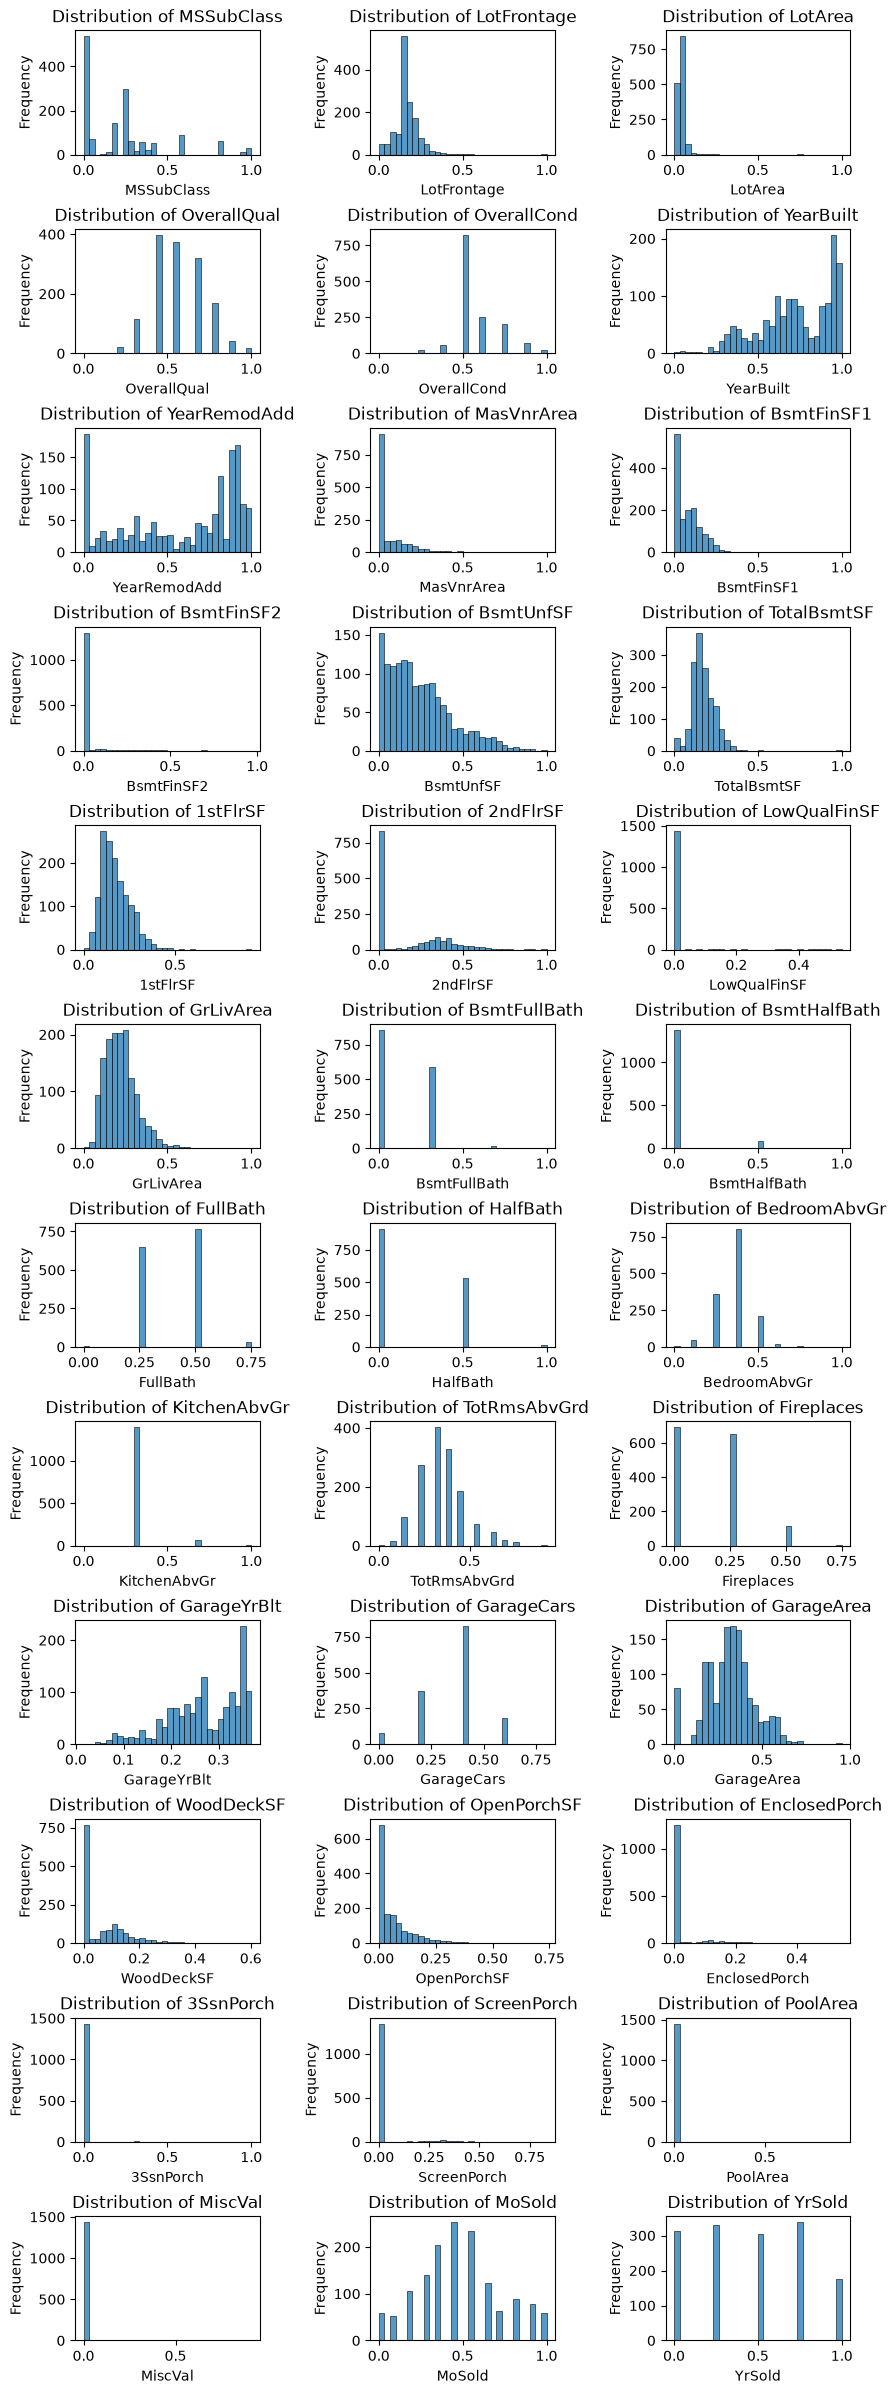

In [4]:

fig, axes = plt.subplots(12, 3, figsize=(10, 30))

plt.subplots_adjust(wspace=0.6, hspace=0.6)
for ax, feature in zip(axes.flat, numeric_feats):
    sns.histplot(
        data=CAx_train,
        x=feature,
        bins=30,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.show()

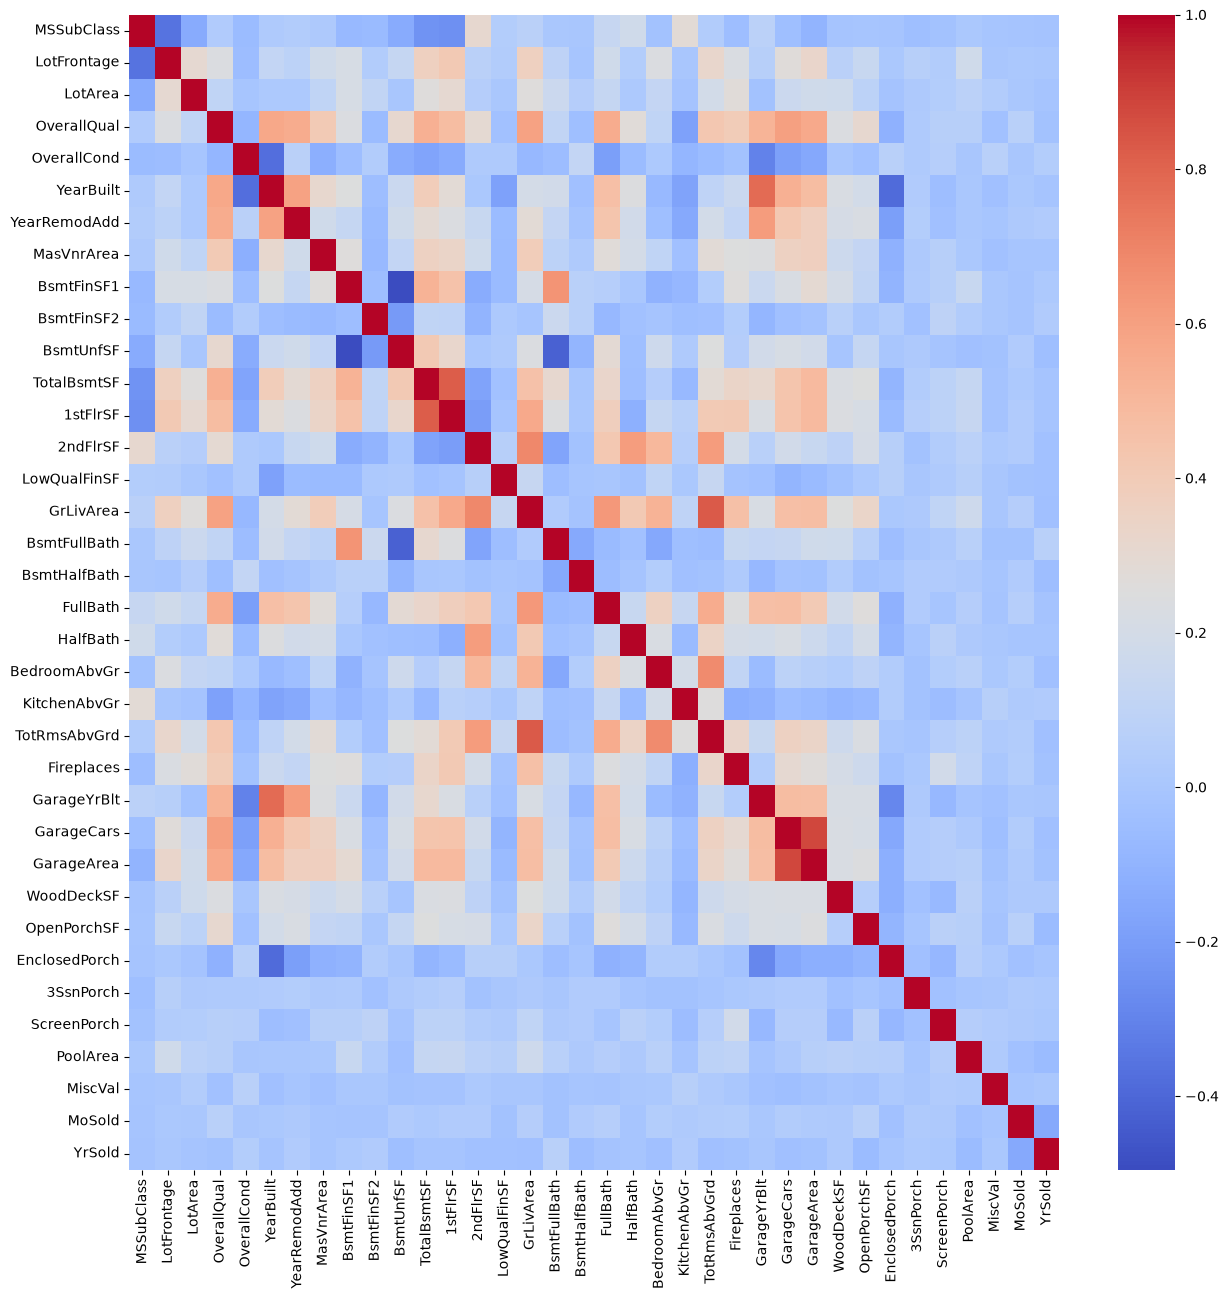

In [16]:
plt.figure(figsize=(15, 15))
sns.heatmap(CAx_train[numeric_feats].corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.savefig("/home/gr00vingm0nkey/vscode/kaggle/Data/house-prices-advanced-regression-techniques/heatmap.png")

In [6]:
CAx_train.to_csv("/home/gr00vingm0nkey/vscode/kaggle/input/house-prices-advanced-regression-techniques/DA_x_train.csv", index=False)
CAy_train.to_csv("/home/gr00vingm0nkey/vscode/kaggle/input/house-prices-advanced-regression-techniques/DA_y_train.csv", index=False)
# CAx_test.to_csv("/home/gr00vingm0nkey/vscode/kaggle/input/house-prices-advanced-regression-techniques/DA_x_test.csv", index=False)

Epoch 1/120


E0000 00:00:1786421251.596239  194215 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786421251.596847  194811 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786421251.623176  194215 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


39/39 - 3s - 78ms/step - loss: 31.6815 - unscaled_rmse: 1446507.7500 - val_loss: 1.0785 - val_unscaled_rmse: 124942.1172
Epoch 2/120
39/39 - 2s - 39ms/step - loss: 0.3990 - unscaled_rmse: 136539.5469 - val_loss: 0.1103 - val_unscaled_rmse: 61698.1562
Epoch 3/120
39/39 - 2s - 45ms/step - loss: 0.0840 - unscaled_rmse: 54989.9219 - val_loss: 0.0785 - val_unscaled_rmse: 53603.6641
Epoch 4/120
39/39 - 2s - 43ms/step - loss: 0.0498 - unscaled_rmse: 43508.8750 - val_loss: 0.0638 - val_unscaled_rmse: 51598.8867
Epoch 5/120
39/39 - 2s - 39ms/step - loss: 0.0366 - unscaled_rmse: 37145.4570 - val_loss: 0.0570 - val_unscaled_rmse: 51267.4297
Epoch 6/120
39/39 - 1s - 37ms/step - loss: 0.0296 - unscaled_rmse: 33213.4375 - val_loss: 0.0508 - val_unscaled_rmse: 48739.0703
Epoch 7/120
39/39 - 1s - 34ms/step - loss: 0.0250 - unscaled_rmse: 30221.6738 - val_loss: 0.0458 - val_unscaled_rmse: 46235.4414
Epoch 8/120
39/39 - 1s - 36ms/step - loss: 0.0215 - unscaled_rmse: 28048.5645 - val_loss: 0.0423 - val_u

AttributeError: module 'matplotlib.pyplot' has no attribute 'ticker'

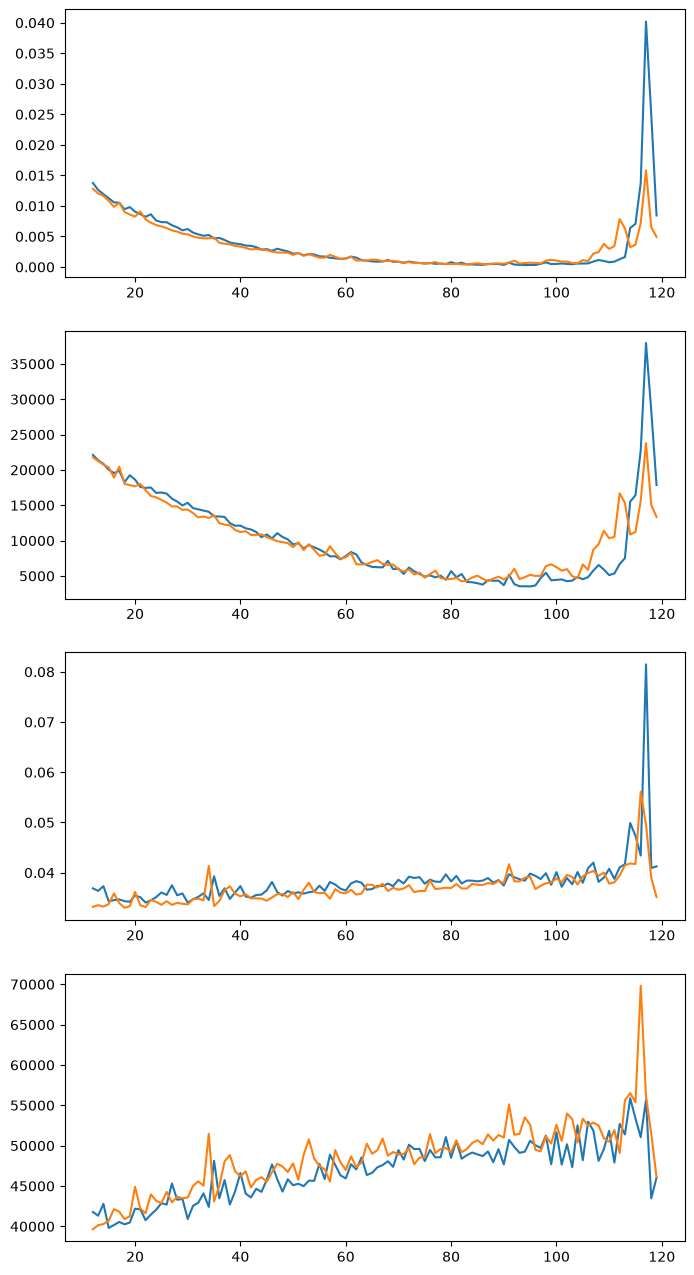

In [ ]:
#model
def Run_Comparision():
    model1 = da.Normal_Model1(2)
    model2 = da.Normal_Model2(2)

    model1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
        loss=keras.losses.MeanSquaredError(),
        metrics=[da.unscaled_rmse]
    )

    model2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
        loss=keras.losses.MeanSquaredError(),
        metrics=[da.unscaled_rmse]
    )

    EPOCHS = 120

    history1 = model1.fit(CAx_train, CAy_train, epochs=EPOCHS, verbose=2, validation_split=0.15)
    history2 = model2.fit(x_train, y_train, epochs=EPOCHS, verbose=2, validation_split=0.15)

    da.Plot_Loss([
        history1.history["loss"],
        history1.history["unscaled_rmse"],
        history1.history["val_loss"],
        history1.history["val_unscaled_rmse"],
        history2.history["loss"],
        history2.history["unscaled_rmse"],
        history2.history["val_loss"],
        history2.history["val_unscaled_rmse"]
    ], [
        "loss1",
        "unscaled_rmse1",
        "val_loss1",
        "val_unscaled_rmse1",
        "loss2",
        "unscaled_rmse2",
        "val_loss2",
        "val_unscaled_rmse2"
    ], [
        0,
        1,
        2,
        3,
        0,
        1,
        2,
        3
    ])

# Run_Comparision()